# 02. Neural Netwrok Classification with PyTorch

## 1. Make classification data and get it ready

In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles

# Make a 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # Add noise
                    random_state=42) # similar to torch.manual_seed
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [ ]:
# Make a DataFrame of circle data
import pandas as pd

circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "label": y})
circles.head(5)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


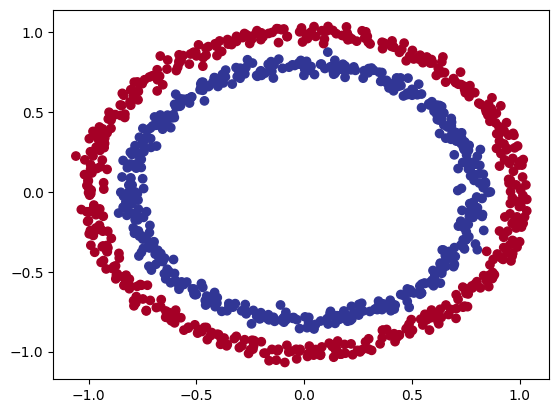

In [ ]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# View the first example of features of labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

### 1.2 Turn data into tensors and create train and test splits

In [ ]:
import torch
torch.__version__

'2.11.0+cu128'

In [ ]:
type(X)

numpy.ndarray

In [ ]:
import torch

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [ ]:
# Split data into train and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.20, # 20% test, 80% train
                                                    random_state=42)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test), n_samples

(800, 200, 800, 200, 1000)

## 2. Build model

classify blue and red dots.
1. Setup device agnostic code
2. Construct a model (by subclassing `nn.Module`)
3. Define loss function, optimizer
4. Create and train and test loop

In [ ]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


Construct model

Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data. Then, define a forward Method


In [ ]:
import torch.nn as nn

In [ ]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # 2 -> 5
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # 5 -> 1
    # self.relu = nn.ReLU()

    # self.two_layers = nn.Sequential(
    #     nn.Linear(in_features=2, out_features=5),
    #     nn.Linear(in_features=5, out_features=1))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    # out = self.layer_2(self.relu(self.layer_1(x)))
    out = self.layer_2(self.layer_1(x))
    return out
    # return self.two_layers(x)

model_0 = CircleModelV0().to(device) # send to device
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Lets create model using nn.Sequential
model_0_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0_1.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5165,  0.6940],
                      [ 0.5895, -0.3121],
                      [ 0.3512,  0.0540],
                      [ 0.5669, -0.1123],
                      [-0.5590,  0.3046]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.5781,  0.6596,  0.5978,  0.5290, -0.6112], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.1771, -0.4081, -0.0474,  0.2916, -0.4085]], device='cuda:0')),
             ('1.bias', tensor([-0.1735], device='cuda:0'))])

In [ ]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
  print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
  print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
  print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
  print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[0.3249],
        [0.4090],
        [0.3736],
        [0.3099],
        [0.8010],
        [0.8490],
        [0.7471],
        [0.8512],
        [0.3555],
        [0.4193]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer

Which loss function or optimizer should we use?

* For regression: MAE(L1) or MSE(L2)
* For classification: BCE, CE

In [ ]:
# Setup loss function
# loss_fn = BCELoss() # required logits to have gone through sigmoid activation function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss has the sigmoid activation function built-in
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)


In [ ]:
# Calculate accuracy
def accuracy_fn(y_true, y_pred):
  correct = (y_pred == y_true).sum().float()
  total = len(y_true)
  acc = (correct / total) * 100.0
  return acc

## 3. Train Model

1. forward pass
2. calculate loss
3. optimizer zero grad
4. backprop
5. optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw logits. We can convert these logits into prediction probabilities by passing them to some kind of activation function (eg: sigmoid for BCE, softmax for multiclass CE)

Then we can convert probabilities into prediction labels by either rounding them or taking `argmax()`.

In [ ]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.3249],
        [0.4090],
        [0.3736],
        [0.3099],
        [0.8010]], device='cuda:0')

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use sigmoid activation function on our model logits.
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5805],
        [0.6008],
        [0.5923],
        [0.5769],
        [0.6902]], device='cuda:0')

For our prediction probability values, we need to perform range-style rounding on them:
* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` < 0.5, `y=1` (class 0)

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0')

### 3.2 Building a train and test loop

In [ ]:
torch.manual_seed(42)

epochs = 100

model_0 = model_0.to(device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_0.train()
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 20 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")

Epoch: 0 | loss: 0.73765 | acc: 50.00% | test_loss: 0.73180 | test_acc: 50.00%
Epoch: 20 | loss: 0.70169 | acc: 55.37% | test_loss: 0.69846 | test_acc: 56.50%
Epoch: 40 | loss: 0.69562 | acc: 51.88% | test_loss: 0.69324 | test_acc: 56.50%
Epoch: 60 | loss: 0.69419 | acc: 51.50% | test_loss: 0.69245 | test_acc: 51.00%
Epoch: 80 | loss: 0.69366 | acc: 51.25% | test_loss: 0.69250 | test_acc: 49.00%


## 4. Make predictions and evaluate model
From the metrics, it looks like our model is not learning anything.

We need to visualize what's going on. We are going to import a function called `plot_decision_boundary()`

In [ ]:
import requests
from pathlib import Path

# Download helper functions from learn pytorch repo.
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


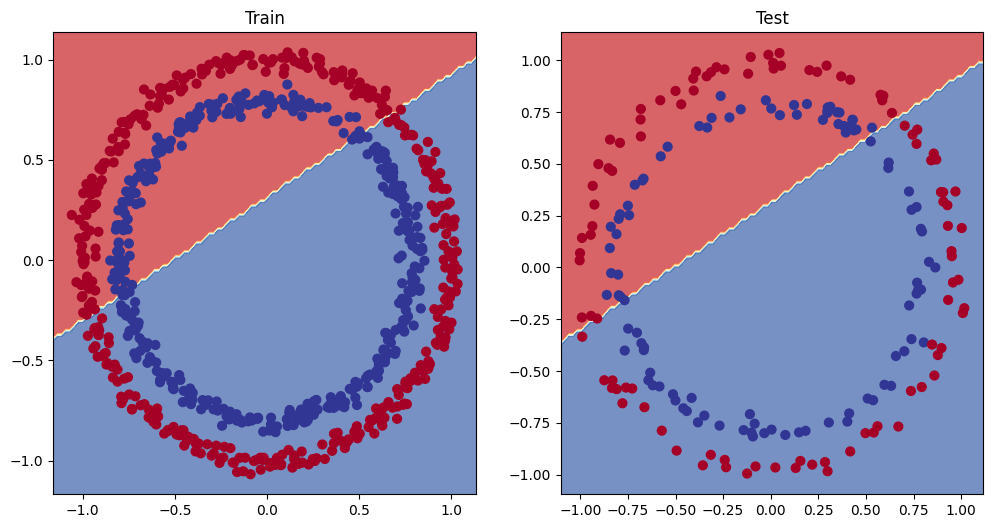

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2) # (rows, cols, idx)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (from a model perspective)

* Add more layers - give the model mor echnages to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    # return z
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# create a loss func
loss_fn = nn.BCEWithLogitsLoss()

# create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [ ]:
# train and test loop model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

model_1 = model_1.to(device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 200 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")


Epoch: 0 | loss: 0.69396 | acc: 50.87% | test_loss: 0.69261 | test_acc: 51.00%
Epoch: 200 | loss: 0.69299 | acc: 51.12% | test_loss: 0.69437 | test_acc: 46.00%
Epoch: 400 | loss: 0.69298 | acc: 51.12% | test_loss: 0.69465 | test_acc: 46.00%
Epoch: 600 | loss: 0.69298 | acc: 51.00% | test_loss: 0.69468 | test_acc: 46.00%
Epoch: 800 | loss: 0.69298 | acc: 51.00% | test_loss: 0.69468 | test_acc: 46.00%


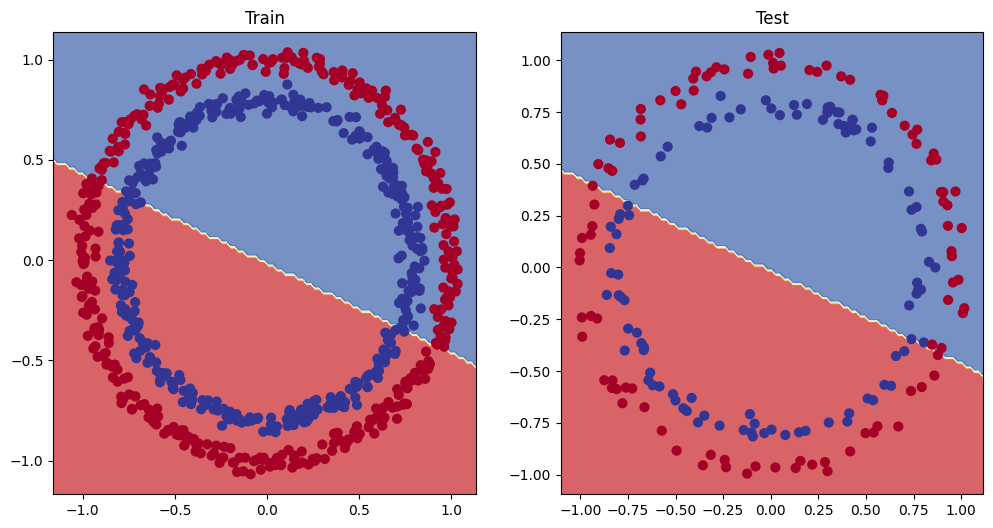

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2) # (rows, cols, idx)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Prepare data to see if our model can fit a straight line

Troubleshoot a larger problem, test out a smaller problem

In [ ]:
# Create some data as notebook_01

weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = X_regression * weight + bias
X_regression.shape, y_regression.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [ ]:
X_regression[:5], y_regression[:5]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# create train test split
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

X_train_regression.shape, y_train_regression.shape, X_test_regression.shape, y_test_regression.shape

(torch.Size([80, 1]),
 torch.Size([80, 1]),
 torch.Size([20, 1]),
 torch.Size([20, 1]))

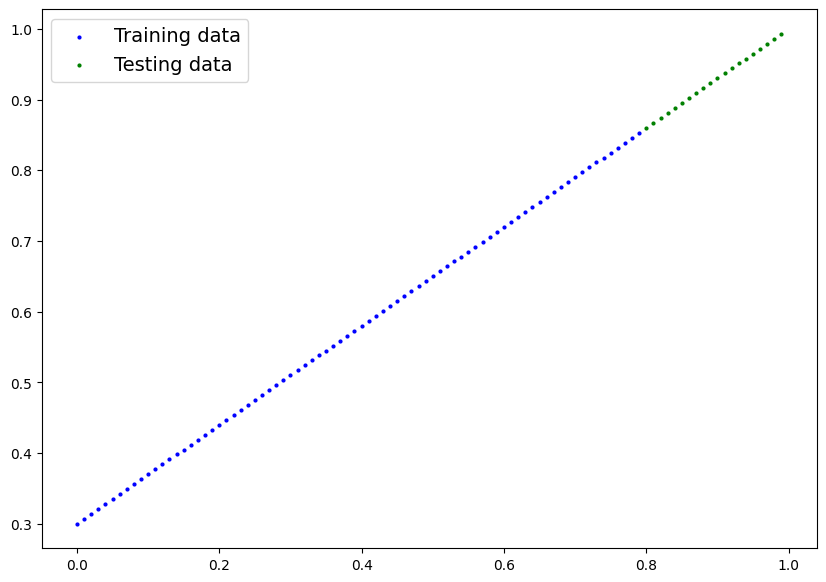

In [ ]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

### 5.2 Adjusting `model_1` to fit a straight line

In [ ]:
# same architecture as model_1 but use nn.Sequential
model_2 = nn.Sequential(
    nn.Linear(1, 10),
    nn.Linear(10, 10),
    nn.Linear(10, 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer
loss_func = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression, X_test_regression, y_test_regression = X_train_regression.to(device), y_train_regression.to(device), X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  model_2.train()
  y_pred = model_2(X_train_regression)

  loss = loss_func(y_pred, y_train_regression)
  acc = accuracy_fn(y_train_regression, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)

    test_loss = loss_func(test_pred, y_test_regression)
    test_acc = accuracy_fn(y_test_regression, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")



Epoch: 0 | loss: 0.75986 | acc: 0.00% | test_loss: 0.91103 | test_acc: 0.00%
Epoch: 100 | loss: 0.02858 | acc: 0.00% | test_loss: 0.00081 | test_acc: 0.00%
Epoch: 200 | loss: 0.02533 | acc: 0.00% | test_loss: 0.00209 | test_acc: 0.00%
Epoch: 300 | loss: 0.02137 | acc: 0.00% | test_loss: 0.00305 | test_acc: 0.00%
Epoch: 400 | loss: 0.01964 | acc: 0.00% | test_loss: 0.00341 | test_acc: 0.00%
Epoch: 500 | loss: 0.01940 | acc: 0.00% | test_loss: 0.00387 | test_acc: 0.00%
Epoch: 600 | loss: 0.01903 | acc: 0.00% | test_loss: 0.00379 | test_acc: 0.00%
Epoch: 700 | loss: 0.01878 | acc: 0.00% | test_loss: 0.00381 | test_acc: 0.00%
Epoch: 800 | loss: 0.01840 | acc: 0.00% | test_loss: 0.00329 | test_acc: 0.00%
Epoch: 900 | loss: 0.01798 | acc: 0.00% | test_loss: 0.00360 | test_acc: 0.00%


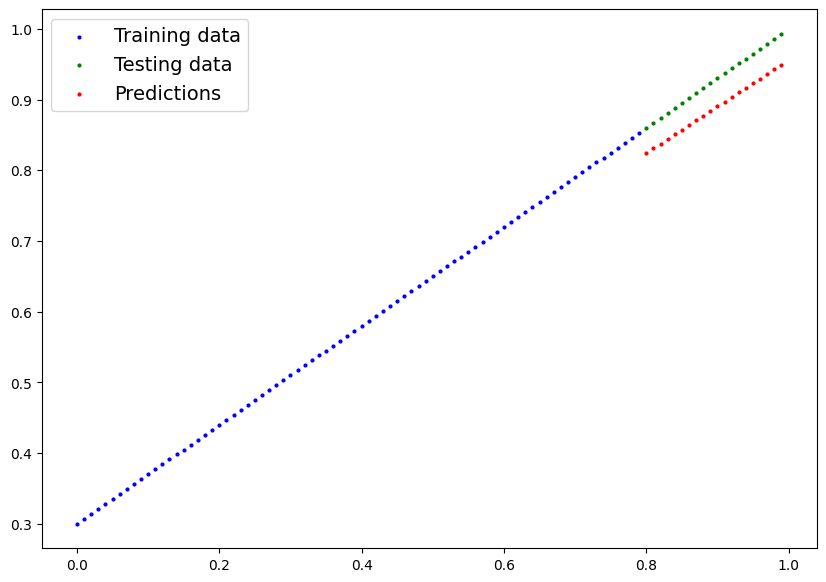

In [ ]:
# X_train_regression, y_train_regression, X_test_regression, y_test_regression = X_train_regression.cpu(), y_train_regression.cpu(), X_test_regression.cpu(), y_test_regression.cpu()

# Eval mode
model_2.eval()

with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())


## 6. The missing piece: non-linearity

### 6.1 Recreate non-linear data (red and blue circles)

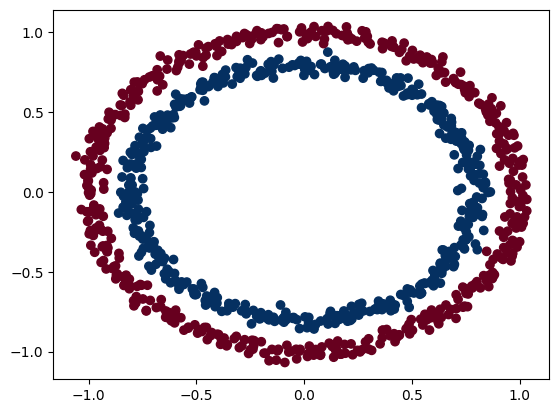

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [ ]:
# Convert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Build a model with non-linear activation

In [ ]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # non-linear activation

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# Loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

### 6.3 Training a model with non-linearity

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 2000

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)
# X_train.shape, y_train.shape, X_test.shape, y_test.shape

for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")


Epoch: 0 | loss: 0.69295 | acc: 50.00% | test_loss: 0.69319 | test_acc: 50.00%
Epoch: 100 | loss: 0.69115 | acc: 52.88% | test_loss: 0.69102 | test_acc: 52.50%
Epoch: 200 | loss: 0.68977 | acc: 53.38% | test_loss: 0.68940 | test_acc: 55.00%
Epoch: 300 | loss: 0.68795 | acc: 53.00% | test_loss: 0.68723 | test_acc: 56.00%
Epoch: 400 | loss: 0.68517 | acc: 52.75% | test_loss: 0.68411 | test_acc: 56.50%
Epoch: 500 | loss: 0.68102 | acc: 52.75% | test_loss: 0.67941 | test_acc: 56.50%
Epoch: 600 | loss: 0.67515 | acc: 54.50% | test_loss: 0.67285 | test_acc: 56.00%
Epoch: 700 | loss: 0.66659 | acc: 58.38% | test_loss: 0.66322 | test_acc: 59.00%
Epoch: 800 | loss: 0.65160 | acc: 64.00% | test_loss: 0.64757 | test_acc: 67.50%
Epoch: 900 | loss: 0.62362 | acc: 74.00% | test_loss: 0.62145 | test_acc: 79.00%
Epoch: 1000 | loss: 0.56818 | acc: 87.75% | test_loss: 0.57378 | test_acc: 86.50%
Epoch: 1100 | loss: 0.48153 | acc: 93.50% | test_loss: 0.49935 | test_acc: 90.50%
Epoch: 1200 | loss: 0.37056 

In [ ]:
model_3.state_dict() # relu does not have any parameters to optimize!

OrderedDict([('layer_1.weight',
              tensor([[ 0.9300,  1.5243],
                      [-0.5232,  1.9216],
                      [-0.1549,  0.1427],
                      [-2.3392, -0.1767],
                      [ 0.6889, -2.3658],
                      [ 1.2308, -0.0741],
                      [ 1.6332,  0.1051],
                      [ 0.3410, -0.0998],
                      [ 0.8671,  0.7070],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.2412, -0.9001, -0.2872, -0.4221, -0.5646, -0.5747, -0.7351, -0.4252,
                      -0.2219, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.0311, -0.7215,  0.2441, -0.3385, -0.4142, -0.0497, -0.2312,  0.2555,
                       -0.1172, -0.0997],
                      [ 1.5930,  1.8717,  0.1331,  2.1387,  2.0953,  1.0247,  1.5361,  0.0566,
                        0.9802, -0.1927],
                      [-0.3130, -0.124

### 6.4 Evaluating model trained with non-linear activation function

In [ ]:
# Make predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test).squeeze()))
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

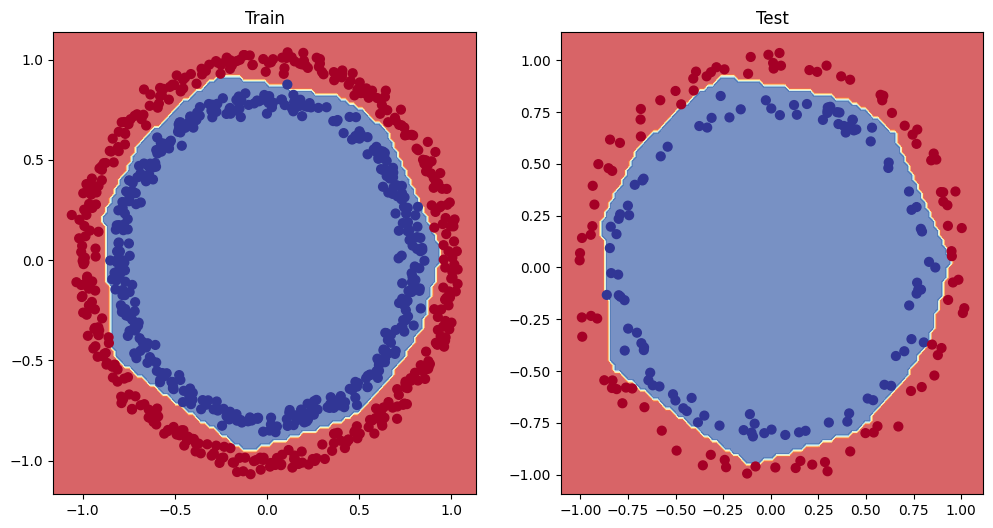

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2) # (rows, cols, idx)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

## 7. Replicating non-linear activation functions

In [ ]:
A = torch.arange(-10, 10, 1.0)
A, A.dtype

(tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
           2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.]),
 torch.float32)

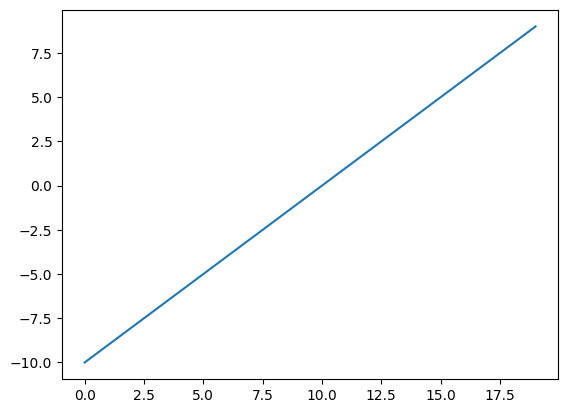

In [ ]:
# Visualize the tensor
plt.plot(A)

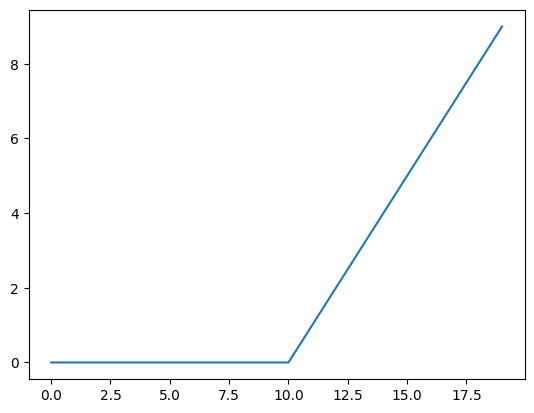

In [ ]:
plt.plot(torch.relu(A))

In [ ]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x)

In [ ]:
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

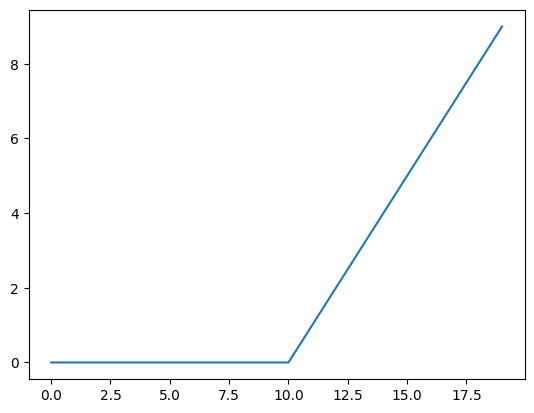

In [ ]:
# Plot ReLU activation function
plt.plot(relu(A))

In [ ]:
# Sigmoid
def sigmoid(x: torch.Tensor) -> torch.Tensor:
  return 1.0 / (1.0 + torch.exp(-x))

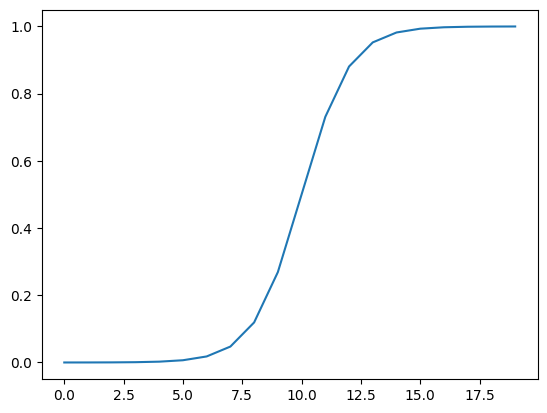

In [ ]:
plt.plot(torch.sigmoid(A))

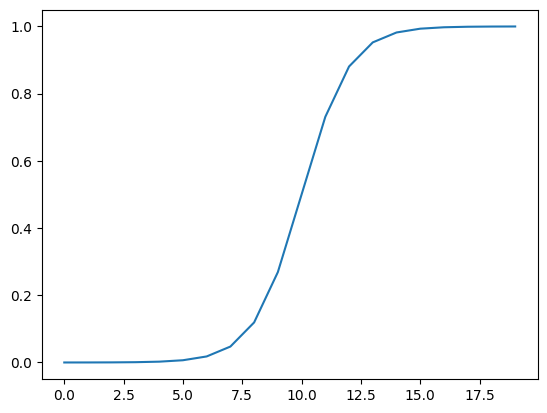

In [ ]:
plt.plot(sigmoid(A))

## 8. Putting it all together with multi-class classification problem

### 8.1 Creating toy multi-class dataset

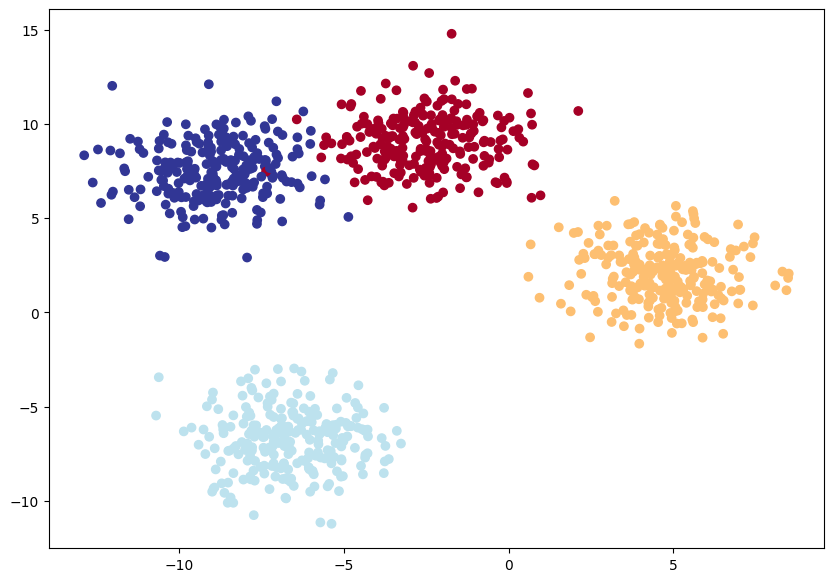

In [ ]:
from numpy._core.defchararray import center
# import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set hyperparameters
NUM_CLASSES = 4
NUM_SAMPLES = 1000
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=NUM_SAMPLES,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)
# 2. turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float) # numpy defaults as float64 but pytorch likes float32
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor) # Cross Entropy does not accept float targets

# 3. Split train test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# 4. Visualize
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

### 8.2 Build multi-class classification model in PyTorch

In [ ]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import torch.nn as nn

# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_features),
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer_stack(x)

model_4 = BlobModel(input_features=2, output_features=4, hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
X_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [ ]:
torch.unique(y_blob_train) # 4 classes

tensor([0, 1, 2, 3], device='cuda:0')

In [ ]:
# Loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

### 8.4 Getting prediction probabilities for multi-class PyTorch model

In [ ]:
model_4.eval()

X_blob_train = X_blob_train.to(device)
X_blob_test = X_blob_test.to(device)
y_blob_train = y_blob_train.to(device)
y_blob_test = y_blob_test.to(device)

with torch.inference_mode():
  logits = model_4(X_blob_test)
# logits -> pred probs -> pred labels
torch.argmax(torch.softmax(logits, dim=1), dim=1)[:10]

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3], device='cuda:0')

In [ ]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

### 8.5 Create train test loop for multi-class PyTorch model

In [ ]:
# Train and test loop

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

epochs = 1000

X_blob_train = X_blob_train.to(device)
X_blob_test = X_blob_test.to(device)
y_blob_train = y_blob_train.to(device)
y_blob_test = y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()
  y_logits = model_4(X_blob_train)
  y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_blob_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)
    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_blob_test, test_pred)

  if epoch % 20 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")

Epoch: 0 | loss: 1.04324 | acc: 65.50% | test_loss: 0.57861 | test_acc: 95.50%
Epoch: 20 | loss: 0.08062 | acc: 99.12% | test_loss: 0.07216 | test_acc: 99.50%
Epoch: 40 | loss: 0.04892 | acc: 99.00% | test_loss: 0.04098 | test_acc: 99.50%
Epoch: 60 | loss: 0.03910 | acc: 99.00% | test_loss: 0.03083 | test_acc: 99.50%
Epoch: 80 | loss: 0.03448 | acc: 99.00% | test_loss: 0.02587 | test_acc: 99.50%
Epoch: 100 | loss: 0.03185 | acc: 99.12% | test_loss: 0.02293 | test_acc: 99.50%
Epoch: 120 | loss: 0.03017 | acc: 99.12% | test_loss: 0.02097 | test_acc: 99.50%
Epoch: 140 | loss: 0.02902 | acc: 99.12% | test_loss: 0.01958 | test_acc: 99.50%
Epoch: 160 | loss: 0.02819 | acc: 99.12% | test_loss: 0.01852 | test_acc: 99.50%
Epoch: 180 | loss: 0.02756 | acc: 99.12% | test_loss: 0.01770 | test_acc: 99.50%
Epoch: 200 | loss: 0.02707 | acc: 99.12% | test_loss: 0.01704 | test_acc: 99.50%
Epoch: 220 | loss: 0.02667 | acc: 99.12% | test_loss: 0.01649 | test_acc: 99.50%
Epoch: 240 | loss: 0.02635 | acc: 

### 8.6 Making and evaluating predictions with a PyTorch multi-class model

In [ ]:
model_4.eval()

X_blob_train = X_blob_train.to(device)
X_blob_test = X_blob_test.to(device)
y_blob_train = y_blob_train.to(device)
y_blob_test = y_blob_test.to(device)

with torch.inference_mode():
  logits = model_4(X_blob_test)
# logits -> pred probs -> pred labels
y_preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

In [ ]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

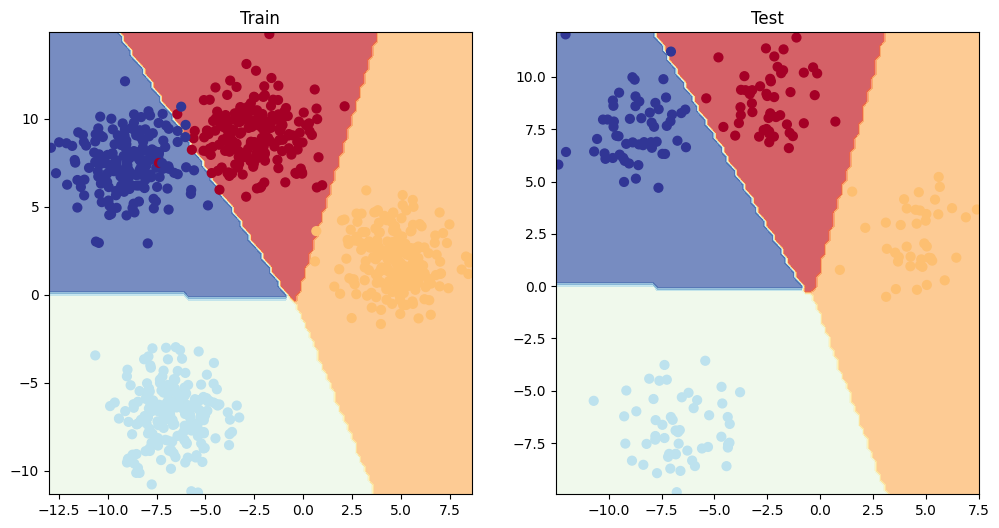

In [ ]:
# Visualize
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics

* Accuracy - out of N samples, how many does our model get right? = `(tp + tn) / (tp + tn + fp + fn)`
* Precision = `tp / (tp + fp)`
* Recall = `tp / (tp + fn)`
* F1-score = `2 * precision * recall / (precision + recall)`
* Confusion matrix - 2D matrix
* Classification report -

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_accuracy = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)

# Calculate accuracy
torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950, device='cuda:0')

## 9. Exercises

https://www.learnpytorch.io/02_pytorch_classification/#exercises

In [118]:
# Import torch
import torch

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"


# Setup random seed
RANDOM_SEED = 42

In [119]:


# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

X_blob, y_blob = make_moons(n_samples=1000,
                            noise=0.2,
                            random_state=RANDOM_SEED)
X_blob.shape, y_blob.shape

((1000, 2), (1000,))

In [120]:
# Turn data into a DataFrame
import pandas as pd

semicircles = pd.DataFrame({'X1': X_blob[:, 0],
                            'X2': X_blob[:, 1],
                            'labels': y_blob})
semicircles.head(5)

,X1,X2,labels
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


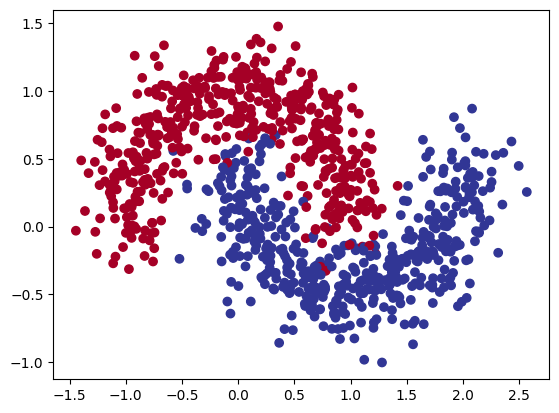

In [121]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt

plt.scatter(x=X_blob[:,0],
            y=X_blob[:,1],
            c=y_blob,
            cmap=plt.cm.RdYlBu)

In [122]:
# Turn data into tensors of dtype float
X = torch.from_numpy(X_blob).type(torch.float32)
# y = torch.from_numpy(y_blob).type(torch.LongTensor)
y = torch.from_numpy(y_blob).type(torch.float32)

# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [123]:
# Build a model by subclassing nn.Module that incorporates non-linear activation
# functions and is capable of fitting the data you created in 1.
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    def __init__(self, in_features, out_features, hidden_units=10):
      super().__init__()
      self.linear_layer_stack = nn.Sequential(
          nn.Linear(in_features=in_features, out_features=hidden_units),
          nn.ReLU(),
          nn.Linear(in_features=hidden_units, out_features=hidden_units),
          nn.ReLU(),
          nn.Linear(in_features=hidden_units, out_features=out_features)
      )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Instantiate the model
## Your code here ##
model_5 = MoonModelV0(2, 1, 10)
model_5

MoonModelV0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [124]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss()

# Setup optimizer to optimize model's parameters
optimizer = torch.optim.SGD(params=model_5.parameters(), lr=0.1)

In [125]:
# What's coming out of our model?
model_5.eval()
with torch.inference_mode():
  # logits (raw outputs of model)
  logits = model_5(X_test).squeeze()
  print("Logits:", logits[:5])

  # Prediction probabilities
  pred_probs = torch.sigmoid(logits)
  print("Pred probs:", pred_probs[:5])

  # Prediction labels
  pred_labels = torch.round(pred_probs)
  print("Pred labels:", pred_labels[:5])

y_test[:5]

Logits: tensor([ 0.0258,  0.0424, -0.0025,  0.0490, -0.0006])
Pred probs: tensor([0.5065, 0.5106, 0.4994, 0.5122, 0.4998])
Pred labels: tensor([1., 1., 0., 1., 0.])


tensor([1., 0., 1., 0., 1.])

In [126]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

# TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [127]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

epochs = 1000

model_5.to(device)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_5.train()

  y_logits = model_5(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_preds, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_5.eval()
  with torch.inference_mode():
    test_logits = model_5(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_preds, y_test)

  if epoch % 100 == 0:
        print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")


Epoch: 0 | loss: 0.69494 | acc: 0.40% | test_loss: 0.69399 | test_acc: 0.50%
Epoch: 100 | loss: 0.40633 | acc: 0.81% | test_loss: 0.42149 | test_acc: 0.77%
Epoch: 200 | loss: 0.28933 | acc: 0.87% | test_loss: 0.28821 | test_acc: 0.86%
Epoch: 300 | loss: 0.26104 | acc: 0.89% | test_loss: 0.25260 | test_acc: 0.88%
Epoch: 400 | loss: 0.24212 | acc: 0.90% | test_loss: 0.23061 | test_acc: 0.89%
Epoch: 500 | loss: 0.21760 | acc: 0.91% | test_loss: 0.20313 | test_acc: 0.90%
Epoch: 600 | loss: 0.18855 | acc: 0.92% | test_loss: 0.17193 | test_acc: 0.93%
Epoch: 700 | loss: 0.15927 | acc: 0.94% | test_loss: 0.14097 | test_acc: 0.94%
Epoch: 800 | loss: 0.13621 | acc: 0.95% | test_loss: 0.11634 | test_acc: 0.97%
Epoch: 900 | loss: 0.11959 | acc: 0.96% | test_loss: 0.09877 | test_acc: 0.98%


In [128]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

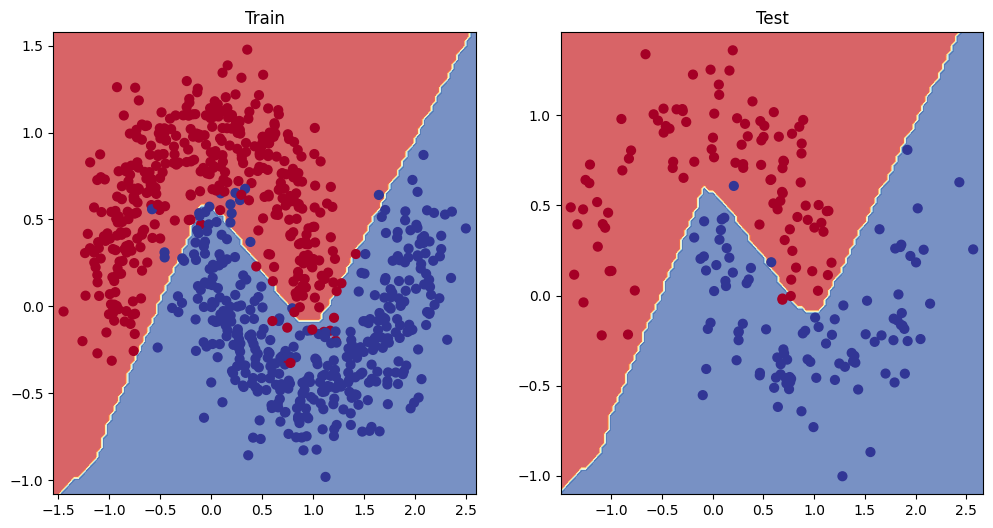

In [129]:
# Visualize
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_5, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_5, X_test, y_test)

In [130]:
# Create a straight line tensor
B = torch.arange(-10, 10, 1, dtype=torch.float32)
B

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [131]:
# Test torch.tanh() on the tensor and plot it
torch.tanh(B)

tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9999, -0.9993, -0.9951,
        -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,  0.9951,  0.9993,  0.9999,
         1.0000,  1.0000,  1.0000,  1.0000])

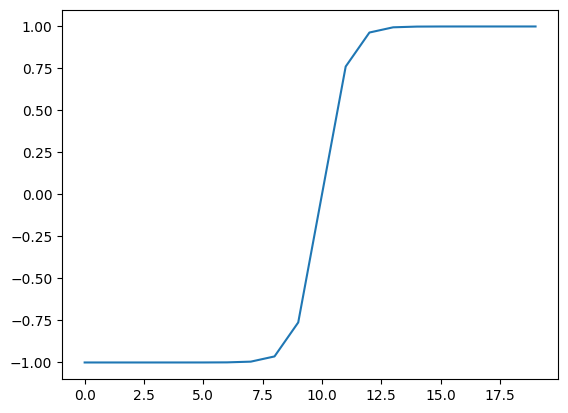

In [132]:
plt.plot(torch.tanh(B))

In [133]:
def tanh(x: torch.Tensor) -> torch.Tensor:
  return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

In [134]:
tanh(B)

tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9999, -0.9993, -0.9951,
        -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,  0.9951,  0.9993,  0.9999,
         1.0000,  1.0000,  1.0000,  1.0000])

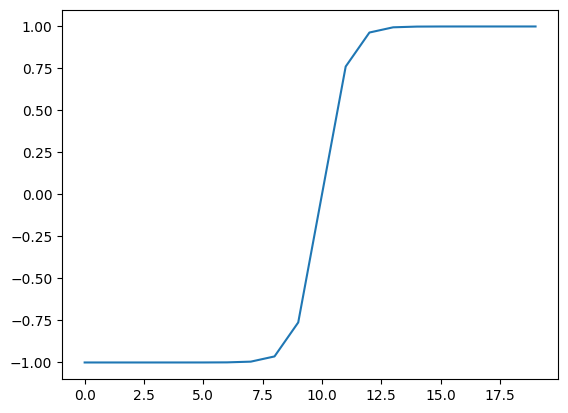

In [135]:
plt.plot(tanh(B))

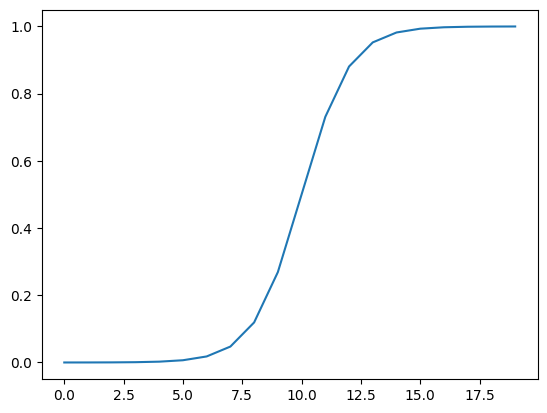

In [136]:
plt.plot(torch.sigmoid(B))

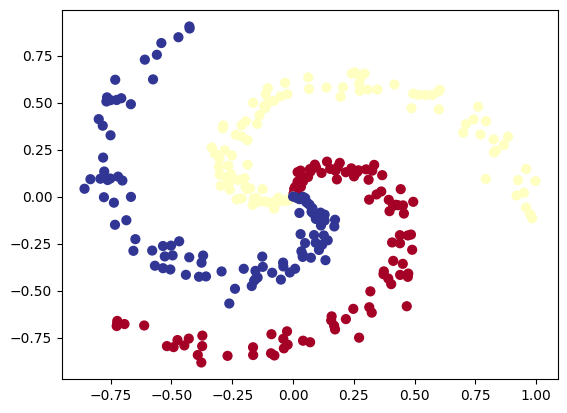

In [137]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [138]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([240, 2]),
 torch.Size([60, 2]),
 torch.Size([240]),
 torch.Size([60]))

In [139]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module
class CS231nModelV0(nn.Module):
  def __init__(self, in_features, out_features, hidden_units=10):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=in_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Instantiate model and send it to device
model_6 = CS231nModelV0(D, K, 10)
model_6

CS231nModelV0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=3, bias=True)
  )
)

In [140]:
# Setup data to be device agnostic
model_6.to(device)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

with torch.inference_mode():
  # Print out first 10 untrained model outputs (forward pass)
  logits = model_6(X_test)
  print("Logits:", logits[:10], logits.shape)

  probs = torch.softmax(logits, dim=1)
  print("Pred probs:", probs[:10], probs.shape)

  labels = torch.argmax(probs, dim=1)
  print("Pred labels:", labels[:10], labels.shape)
y_test[:10]

Logits: tensor([[-0.2213, -0.0604,  0.2361],
        [-0.2309, -0.0634,  0.2455],
        [-0.2226, -0.0530,  0.2443],
        [-0.2226, -0.0603,  0.2396],
        [-0.2153, -0.0594,  0.2261],
        [-0.2163, -0.0591,  0.2292],
        [-0.2093, -0.0528,  0.2865],
        [-0.2229, -0.0623,  0.2335],
        [-0.2227, -0.0608,  0.2380],
        [-0.2204, -0.0525,  0.2818]]) torch.Size([60, 3])
Pred probs: tensor([[0.2664, 0.3128, 0.4208],
        [0.2637, 0.3117, 0.4246],
        [0.2646, 0.3135, 0.4220],
        [0.2657, 0.3125, 0.4218],
        [0.2686, 0.3139, 0.4176],
        [0.2680, 0.3136, 0.4184],
        [0.2624, 0.3068, 0.4308],
        [0.2665, 0.3129, 0.4206],
        [0.2659, 0.3126, 0.4215],
        [0.2607, 0.3084, 0.4308]]) torch.Size([60, 3])
Pred labels: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2]) torch.Size([60])


tensor([2, 2, 1, 0, 2, 2, 1, 1, 0, 1])

In [141]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_6.parameters(), lr=0.1)

In [142]:
acc_fn = Accuracy(task="multiclass", num_classes=K).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [143]:
# Build a training loop for the model
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

epochs = 2000

# Loop over data
for epoch in range(epochs):
  model_6.train()

  y_logits = model_6(X_train)
  y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_preds, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_6.eval()
  with torch.inference_mode():
    test_logits = model_6(X_test)
    test_preds = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_preds, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.05f} | acc: {acc:.2f}% | test_loss: {test_loss:.5f} | test_acc: {test_acc:.2f}%")


Epoch: 0 | loss: 1.11747 | acc: 0.32% | test_loss: 1.10989 | test_acc: 0.37%
Epoch: 100 | loss: 1.08143 | acc: 0.45% | test_loss: 1.08688 | test_acc: 0.40%
Epoch: 200 | loss: 1.01964 | acc: 0.49% | test_loss: 1.02548 | test_acc: 0.47%
Epoch: 300 | loss: 0.92621 | acc: 0.52% | test_loss: 0.93808 | test_acc: 0.47%
Epoch: 400 | loss: 0.85709 | acc: 0.54% | test_loss: 0.88026 | test_acc: 0.47%
Epoch: 500 | loss: 0.78542 | acc: 0.57% | test_loss: 0.81779 | test_acc: 0.47%
Epoch: 600 | loss: 0.72140 | acc: 0.62% | test_loss: 0.76234 | test_acc: 0.58%
Epoch: 700 | loss: 0.67026 | acc: 0.66% | test_loss: 0.71268 | test_acc: 0.62%
Epoch: 800 | loss: 0.63571 | acc: 0.66% | test_loss: 0.67535 | test_acc: 0.60%
Epoch: 900 | loss: 0.61094 | acc: 0.66% | test_loss: 0.64543 | test_acc: 0.62%
Epoch: 1000 | loss: 0.59008 | acc: 0.67% | test_loss: 0.61970 | test_acc: 0.63%
Epoch: 1100 | loss: 0.52010 | acc: 0.73% | test_loss: 0.56055 | test_acc: 0.67%
Epoch: 1200 | loss: 0.46809 | acc: 0.77% | test_loss

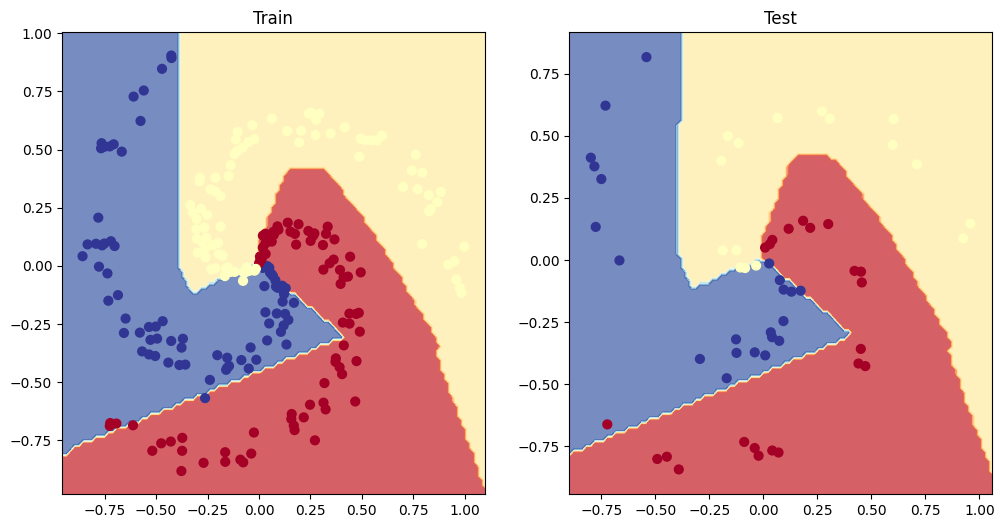

In [144]:
# Visualize
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_6, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_6, X_test, y_test)